## Finding the best data transformation with Randomized Search

In a [previous notebook](https://www.kaggle.com/solegalli/feature-engineering-pipeline-and-hyperparam-tuning), I made a grid search to optimize the hyperparameters of various feature engineering transformers and a gradient boosting classifier.

What if I am not sure which transformer to use to begin with? Can I also make a search to find the best transformation?

Yes, we can!

In this notebook, I will:

- assemble a feature engineering pipeline
- automatically find out the best data transformation
- train a Logistic Regression

Using Randomized search.

We will:

- set up a series of feature engineering steps using [Feature-engine](https://feature-engine.readthedocs.io/en/latest/index.html)
- train a Logistic Regression
- train the pipeline with cross-validation, looking over different feature-engineering transformation and model hyperparameters

For more details on feature engineering and hyperparameter optimization feel free to check my [online courses](https://www.trainindata.com/).

In [ ]:
# Let's install Feature-engine
# an open-source Python library for feature engineering
# it allows us to select which features we want to transform
# straight-away from within each transformer

# https://feature-engine.readthedocs.io/en/latest/index.html

!pip install feature-engine

     |████████████████████████████████| 180 kB 906 kB/s 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# for the model
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    )

# for feature engineering
from feature_engine import imputation as mdi
from feature_engine import encoding as ce
from feature_engine import discretisation as disc
from feature_engine import transformation as t

## Load the data

In [ ]:
data = pd.read_csv("/kaggle/input/titanic/train.csv")

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# the aim of this notebook is to show how to select the best data
# transformations

# So I will take a shortcut and remove some features to make things simpler

cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
    'Embarked', 'Survived'
]

data = data[cols]

data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,male,22.0,1,0,7.2500,NaN,S,0
1,1,female,38.0,1,0,71.2833,C85,C,1
2,3,female,26.0,0,0,7.9250,NaN,S,1
3,1,female,35.0,1,0,53.1000,C123,S,1
4,3,male,35.0,0,0,8.0500,NaN,S,0


In [ ]:
# Cabin: extract numerical and categorical part and delete original variable

data['cabin_num'] = data['Cabin'].str.extract('(\d+)') # captures numerical part
data['cabin_num'] = data['cabin_num'].astype('float')
data['cabin_cat'] = data['Cabin'].str[0] # captures the first letter

data.drop(['Cabin'], axis=1, inplace=True)

data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,cabin_num,cabin_cat
0,3,male,22.0,1,0,7.2500,S,0,NaN,NaN
1,1,female,38.0,1,0,71.2833,C,1,85.0,C
2,3,female,26.0,0,0,7.9250,S,1,NaN,NaN
3,1,female,35.0,1,0,53.1000,S,1,123.0,C
4,3,male,35.0,0,0,8.0500,S,0,NaN,NaN


In [ ]:
# make list of variables types
# we need these lists to tell Feature-engine which variables it should modify

# numerical: discrete
discrete = [
    var for var in data.columns if data[var].dtype != 'O' and var != 'Survived'
    and data[var].nunique() < 10
]

# numerical: continuous
continuous = [
    var for var in data.columns
    if data[var].dtype != 'O' and var != 'Survived' and var not in discrete
]

# categorical
categorical = [var for var in data.columns if data[var].dtype == 'O']

print('There are {} discrete variables'.format(len(discrete)))
print('There are {} continuous variables'.format(len(continuous)))
print('There are {} categorical variables'.format(len(categorical)))

There are 3 discrete variables
There are 3 continuous variables
There are 3 categorical variables


In [ ]:
# discrete variables

discrete

['Pclass', 'SibSp', 'Parch']

In [ ]:
# continuous variables

continuous

['Age', 'Fare', 'cabin_num']

In [ ]:
# categorical variables

categorical

['Sex', 'Embarked', 'cabin_cat']

In [ ]:
# separate into training and testing set

X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Survived', axis=1),  # predictors
    data['Survived'],  # target
    test_size=0.1,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((801, 9), (90, 9))

### Set up the pipeline

I want to assemble a pipeline that contains the following steps:

- impute numerical variables
- impute categorical variables
- encode categorical variables
- either discretise or transform continuous variables
- scale all variables
- train a logistic regression

But I am unsure of the way to select the best imputation methods, the best encoding method, or if I should transform or discretise the continuous variables.

Let's take it one step at the time.

In [ ]:
# Numerical imputation:
#----------------------

# Should I do mean, median imputation or imputation with an arbitrary value?

mean_imputer = mdi.MeanMedianImputer(imputation_method = 'mean', variables=['Age', 'Fare', 'cabin_num'])

median_imputer = mdi.MeanMedianImputer(imputation_method = 'median', variables=['Age', 'Fare', 'cabin_num'])

arbitrary_imputer = mdi.EndTailImputer(variables=['Age', 'Fare', 'cabin_num'])

num_imputer = [mean_imputer, median_imputer, arbitrary_imputer]

In [ ]:
# Categorical encoding

# Should I do one hot? ordinal imputation or mean encoding?

onehot_enc = ce.OneHotEncoder(variables=categorical)
ordinal_enc = ce.OrdinalEncoder(encoding_method='ordered', variables=categorical)
mean_enc = ce.MeanEncoder(variables=categorical)

cat_encoder = [onehot_enc, ordinal_enc, mean_enc]

In [ ]:
# Continuous variables

# should I discretise them or transform them?

efd = disc.EqualFrequencyDiscretiser(q=5, variables=continuous)
dtd = disc.DecisionTreeDiscretiser(variables=continuous)

yj = t.YeoJohnsonTransformer(variables=continuous)

transformers = [efd, dtd, yj]

In [ ]:
# finally, I want to scale the variables before passing them
# to the logit:

scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]

In [ ]:
# Now I set up the pipeline with some parameters.
# We will modify the steps later during the random search


titanic_pipe = Pipeline([

    # missing data imputation - numerical
    ('imputer_num', mean_imputer),

    # missind data imputation - categorical
    ('imputer_cat', mdi.CategoricalImputer(variables=['Embarked', 'cabin_cat'])),

    # categorical encoding - we will group rare categories into 1
    ('encoder_rare_label', ce.RareLabelEncoder(
        tol=0.01,
        n_categories=2,
        variables=['Embarked', 'cabin_cat'],
    )),

    # categorical encoding (into numbers)
    ('categorical_encoder', onehot_enc),

    # continuous variable transformation
    ('transformation', efd),

    # variable scaling
    ('scalers', StandardScaler),

    # Logistic regression
    ('logit', LogisticRegression(random_state=0))
])

## Random Search with Cross-validation

For hyperparameter search we need:

- the machine learning pipeline that we want to optimize (in the previous cell)
- the hyperparamter space that we want to sample (next cell)
- a metric to optimize
- an algorithm to sample the hyperparameters (Random Search in this case)

Let's do that.

In [ ]:
# not we enter into the param_grid, the different options
# that we want to test

param_grid = {

    # test different numerical variable imputation
    'imputer_num': num_imputer,

    # test imputation with frequent category or string missing
    # we modify the paramater of the feature-engine transformer directly
    'imputer_cat__imputation_method': ['missing','frequent'],

    # test different thresholds to group rare labels
    # we modify the paramater of the feature-engine transformer directly
    'encoder_rare_label__tol': stats.uniform(0.1, 0.2),

    # test different encoding strategies
    'categorical_encoder': cat_encoder,

    # test different variable transformation strategies
    'transformation': transformers,

    # test different scalers
    'scalers': scalers,

    # try different logistic regression hyperparamenters
    'logit__C': stats.uniform(0, 1),
}

# (note how we call the step name in the pipeline followed by __
# followed by the name of the hyperparameter that we want to modify
# when we want to access directly the parameters inside the pipeline step)

In [ ]:
# now we set up the randomized search with cross-validation

search = RandomizedSearchCV(
    titanic_pipe, # the pipeline
    param_grid, # the hyperparameter space
    cv=3, # the cross-validation
    scoring='roc_auc', # the metric to optimize
    n_iter = 20, # the number of combinations to sample,
)

# for more details in the randomized search visit:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

In [ ]:
# and now we train over all the possible combinations of the parameters
# specified above

search.fit(X_train, y_train)

# and we print the best score over the train set
print(("best roc-auc from search: %.3f" % search.score(X_train, y_train)))

best roc-auc from search: 0.861


In [ ]:
# and finally let's check the performance over the test set

print(("best linear regression from grid search: %.3f" %search.score(X_test, y_test)))

best linear regression from grid search: 0.908


In [ ]:
# we can find the best pipeline with its parameters like this

search.best_estimator_

Pipeline(steps=[('imputer_num',
                 MeanMedianImputer(variables=['Age', 'Fare', 'cabin_num'])),
                ('imputer_cat',
                 CategoricalImputer(imputation_method='frequent',
                                    variables=['Embarked', 'cabin_cat'])),
                ('encoder_rare_label',
                 RareLabelEncoder(n_categories=2, tol=0.2582335468297282,
                                  variables=['Embarked', 'cabin_cat'])),
                ('categorical_encoder',
                 MeanEncoder(variables=['Sex', 'Embarked', 'cabin_cat'])),
                ('transformation',
                 YeoJohnsonTransformer(variables=['Age', 'Fare', 'cabin_num'])),
                ('scalers', StandardScaler()),
                ('logit',
                 LogisticRegression(C=0.5515292999269383, random_state=0))])

In [ ]:
# and find the best fit parameters like this

search.best_params_

{'categorical_encoder': MeanEncoder(variables=['Sex', 'Embarked', 'cabin_cat']),
 'encoder_rare_label__tol': 0.2582335468297282,
 'imputer_cat__imputation_method': 'frequent',
 'imputer_num': MeanMedianImputer(variables=['Age', 'Fare', 'cabin_num']),
 'logit__C': 0.5515292999269383,
 'scalers': StandardScaler(),
 'transformation': YeoJohnsonTransformer(variables=['Age', 'Fare', 'cabin_num'])}

In the previous cell we can see which were the data transformations that worked best.

In [ ]:
# we also find the data for all models evaluated

results = pd.DataFrame(search.cv_results_)

print(results.shape)

results.head()

(20, 18)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_categorical_encoder,param_encoder_rare_label__tol,param_imputer_cat__imputation_method,param_imputer_num,param_logit__C,param_scalers,param_transformation,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.049701,0.005933,0.015805,0.000603,"OneHotEncoder(variables=['Sex', 'Embarked', 'c...",0.279002,missing,"MeanMedianImputer(variables=['Age', 'Fare', 'c...",0.497502,StandardScaler(),"EqualFrequencyDiscretiser(q=5, variables=['Age...",{'categorical_encoder': OneHotEncoder(variable...,0.832757,0.841525,0.868633,0.847638,0.015271,8
1,0.051182,0.001847,0.014715,0.000128,"OrdinalEncoder(variables=['Sex', 'Embarked', '...",0.241056,frequent,"EndTailImputer(variables=['Age', 'Fare', 'cabi...",0.89339,MinMaxScaler(),"EqualFrequencyDiscretiser(q=5, variables=['Age...",{'categorical_encoder': OrdinalEncoder(variabl...,0.831087,0.843582,0.857092,0.843920,0.010619,17
2,0.050405,0.000501,0.012999,0.000328,"MeanEncoder(variables=['Sex', 'Embarked', 'cab...",0.214348,frequent,"MeanMedianImputer(variables=['Age', 'Fare', 'c...",0.156741,StandardScaler(),"YeoJohnsonTransformer(variables=['Age', 'Fare'...",{'categorical_encoder': MeanEncoder(variables=...,0.840839,0.850650,0.876625,0.856038,0.015098,2
3,0.193186,0.004510,0.016665,0.000142,"MeanEncoder(variables=['Sex', 'Embarked', 'cab...",0.150968,frequent,"MeanMedianImputer(imputation_method='mean',\n ...",0.309765,StandardScaler(),"DecisionTreeDiscretiser(variables=['Age', 'Far...",{'categorical_encoder': MeanEncoder(variables=...,0.839467,0.841316,0.858792,0.846525,0.008707,10
4,0.052272,0.001140,0.014491,0.000142,"MeanEncoder(variables=['Sex', 'Embarked', 'cab...",0.130247,frequent,"EndTailImputer(variables=['Age', 'Fare', 'cabi...",0.926936,RobustScaler(),"EqualFrequencyDiscretiser(q=5, variables=['Age...",{'categorical_encoder': MeanEncoder(variables=...,0.835978,0.845312,0.855988,0.845759,0.008175,13


Text(0.5, 0, 'Hyperparameter combinations')

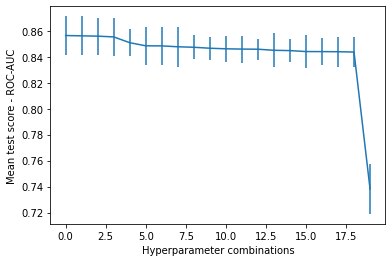

In [ ]:
# we can order the different models based on their performance

results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)


# plot model performance and the generalization error

results['mean_test_score'].plot(yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean test score - ROC-AUC')
plt.xlabel('Hyperparameter combinations')

If you liked this notebook and would like to know more about feature engineering and hyperparameter optimization feel free to check my [online courses](https://www.trainindata.com/).